In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

import numpy as np
from pathlib import Path

processed_path = Path("../data/splits/2026-08-16_processed_data_no_duplicates.npz")

data = np.load(processed_path)

print(data.files)

2026-08-31 08:58:19.887724: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-31 08:58:20.026873: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-31 08:58:22.567717: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [2]:
# Datos de Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos de SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Aplicamos la normalización que mejores resultados dio en la red neuronal densa.

In [3]:
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

y_scale_train = np.nanmedian(np.abs(y_train), axis=1, keepdims=True)
y_scale_val = np.nanmedian(np.abs(y_val), axis=1, keepdims=True)
y_scale_test = np.nanmedian(np.abs(y_test), axis=1, keepdims=True)

X_train_norm_median_spec = X_train / X_scale_train
X_val_norm_median_spec = X_val / X_scale_val
X_test_norm_median_spec = X_test / X_scale_test

y_train_norm_median_spec = y_train / y_scale_train
y_val_norm_median_spec = y_val / y_scale_val
y_test_norm_median_spec = y_test / y_scale_test

Preparamos los datos para la RNN añadiendo una tercera dimensión para las variables por cada paso (punto de la longitud de onda).

In [4]:
X_train_rnn = X_train_norm_median_spec[..., np.newaxis]
X_val_rnn = X_val_norm_median_spec[..., np.newaxis]
X_test_rnn = X_test_norm_median_spec[..., np.newaxis]

print("X_train_rnn:", X_train_rnn.shape)
print("X_val_rnn:", X_val_rnn.shape)
print("X_test_rnn:", X_test_rnn.shape)

X_train_rnn: (32656, 201, 1)
X_val_rnn: (4082, 201, 1)
X_test_rnn: (4082, 201, 1)


Definimos un primer modelo base para hacer pruebas.

In [5]:
n_gaia = X_train_rnn.shape[1]
n_features = X_train_rnn.shape[2]
n_sdss = y_train_norm_median_spec.shape[1]

Definimos las mismas funciones que en el caso denso. 

In [6]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [7]:
model_GRU = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.GRU(128, return_sequences=False),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(n_sdss)
])

model_GRU.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_GRU.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,374,314 (12.87 MB)

 Trainable params: 3,374,314 (12.87 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_GRU = model_GRU.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 124s 237ms/step - loss: 0.2043 - mae: 0.4750 - mse: 0.4542 - val_loss: 0.0117 - val_mae: 0.0827 - val_mse: 0.0322 - learning_rate: 1.0000e-04
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 98s 192ms/step - loss: 0.0104 - mae: 0.0796 - mse: 0.0259 - val_loss: 0.0082 - val_mae: 0.0668 - val_mse: 0.0233 - learning_rate: 1.0000e-04
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 81s 158ms/step - loss: 0.0080 - mae: 0.0676 - mse: 0.0200 - val_loss: 0.0073 - val_mae: 0.0634 - val_mse: 0.0203 - learning_rate: 1.0000e-04
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 78s 153ms/step - loss: 0.0071 - mae: 0.0632 - mse: 0.0173 - val_loss: 0.0070 - val_mae: 0.0624 - val_mse: 0.0192 - learning_rate: 1.0000e-04
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 72s 140ms/step - loss: 0.0069 - mae: 0.0629 - mse: 0.0163 - val_loss: 0.0067 - val_mae: 0.0597 - val_mse: 0.0185 - learning_rate: 1.0000e-04
Epoch 6/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 72s 142ms/step - loss: 0.0067 - mae: 0.0617 - mse: 0.0

In [9]:
test_results_GRU = model_GRU.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0045 - mae: 0.0489 - mse: 0.0124


In [10]:
y_pred_norm_GRU= model_GRU.predict(X_test_norm_median_spec)
y_pred_spec_GRU = y_pred_norm_GRU* y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


In [11]:
predictions_path = Path("../data/predictions/predicciones_GRU.npz")
predictions_path.parent.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    predictions_path,
    y_pred_GRU = y_pred_spec_GRU
)

In [14]:
import sys
from pathlib import Path

# Localizamos la carpeta 'solution' subiendo desde el directorio de trabajo, sin
# suponer dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como
# 'models' o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

ISPEC_FUNCTIONS_DIR = Path(
    "/Users/carlasequero/Desktop/trabajo-fin-master/solution/models"
)

if str(ISPEC_FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(ISPEC_FUNCTIONS_DIR))

# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# Cargamos Resources
resources = load_ispec_resources()

from astropy.table import Table
# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("../data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()


ModuleNotFoundError: No module named 'ispec'

In [ ]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
results_df_GRU = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_GRU,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando espectro real
Error analizando espectro real






Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


[2026-08-31 14:58:16,283] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.6911155921887793 -4.559396401646449 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-31 14:58:17,398] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-31 14:58:23,706] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.9241712654505534 -4.433403594361867 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-31 14:58:24,828] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-31 14:58:31,043] [WARNING] [atmospheres:_interpolate:110]: Target point '3538.7181018573174 2.120410924434774 -4.114757058198167 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-3

Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


[2026-08-31 15:53:46,842] [WARNING] [atmospheres:_interpolate:110]: Target point '6888.546021266449 4.398305695395245 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-31 15:53:47,953] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando espectro real


In [ ]:

ispec_path = Path("../data/predictions/ispec_GRU.csv")
ispec_path.parent.mkdir(parents=True, exist_ok=True)

results_df_GRU.to_csv(
    ispec_path,
    index=False
)

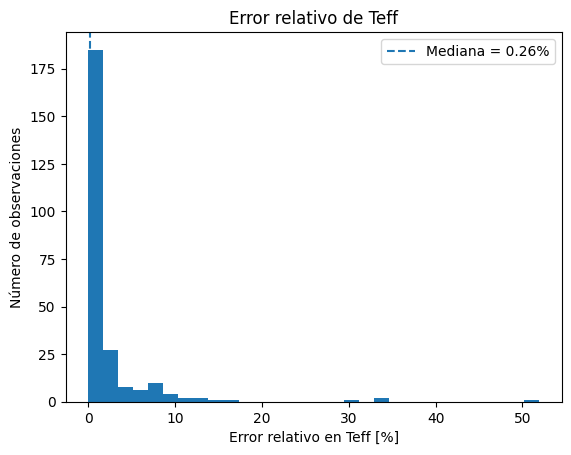

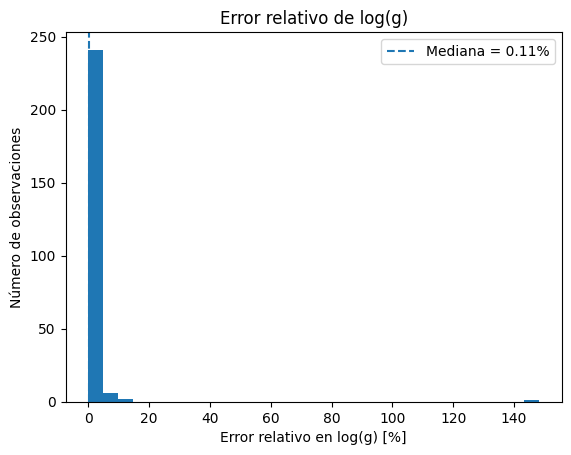

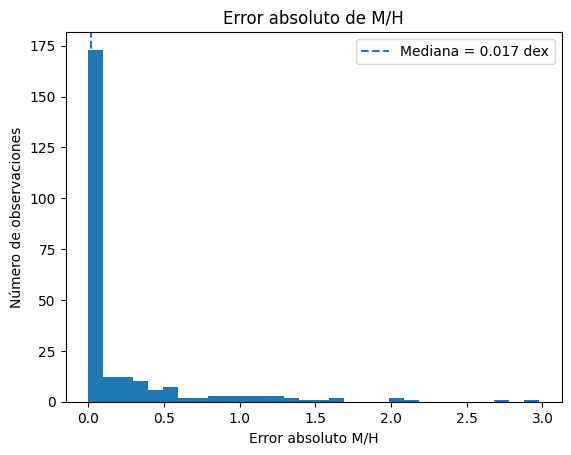

In [ ]:
error_df_GRU = analyze_ispec_errors(results_df_GRU)

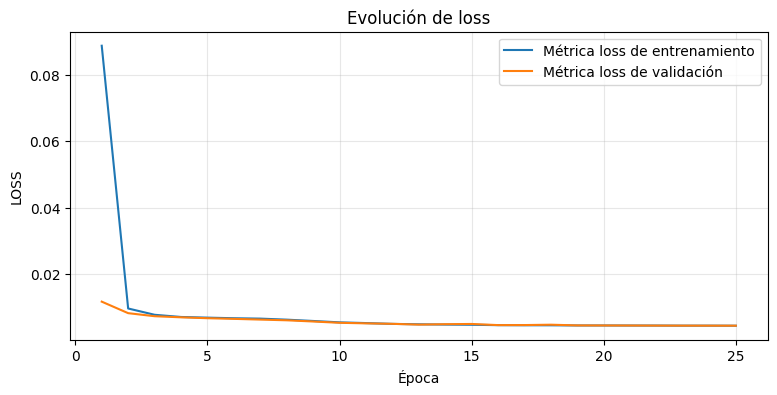

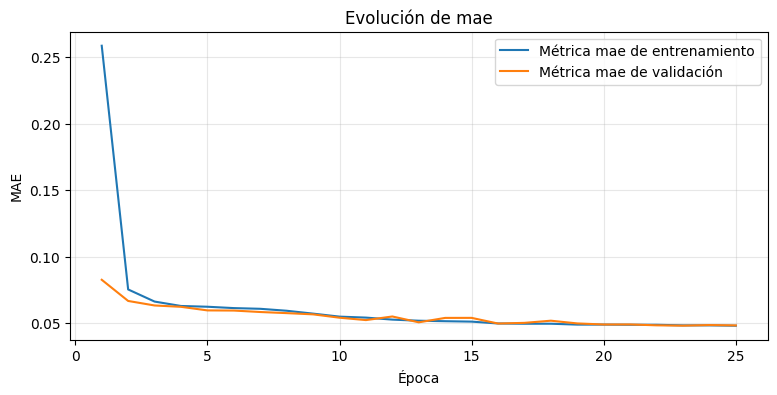

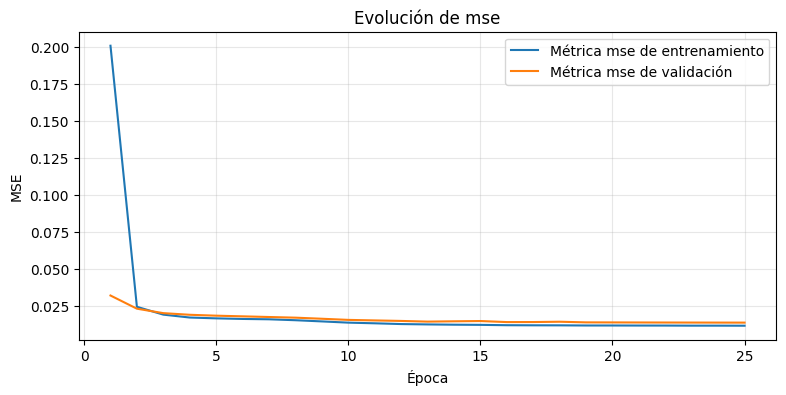

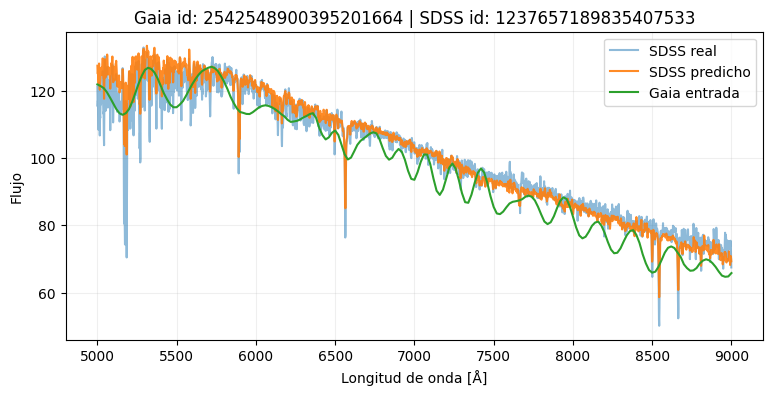

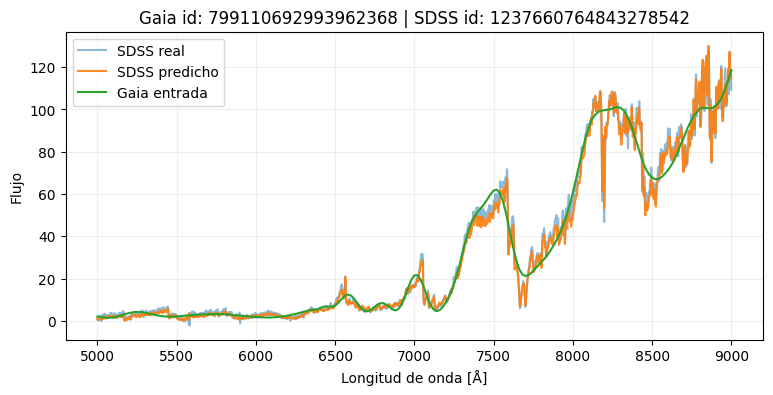

In [15]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

model_data_GRU = history_GRU.history
plot_training_metrics(model_data_GRU)

plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_GRU,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_GRU,
    y_id_test,
    X_test,
    X_id_test
)

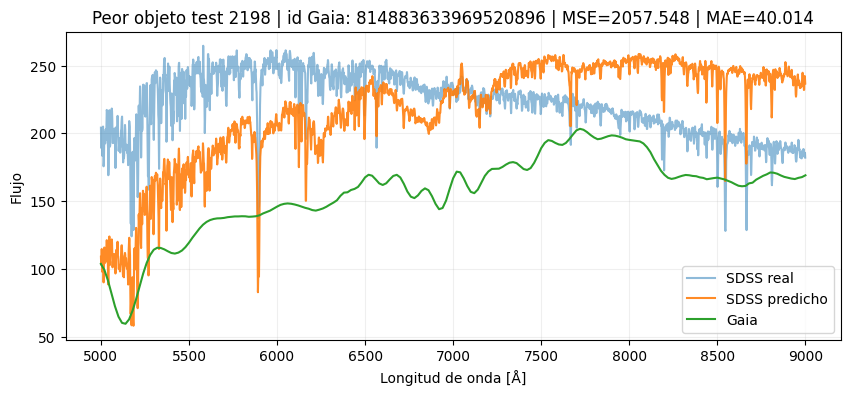

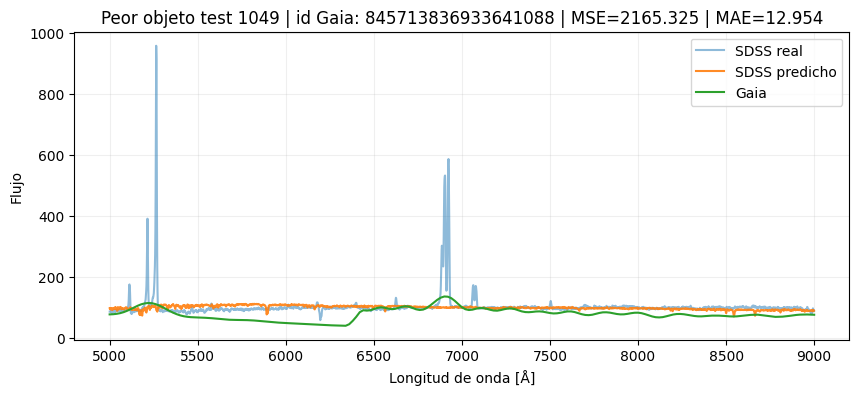

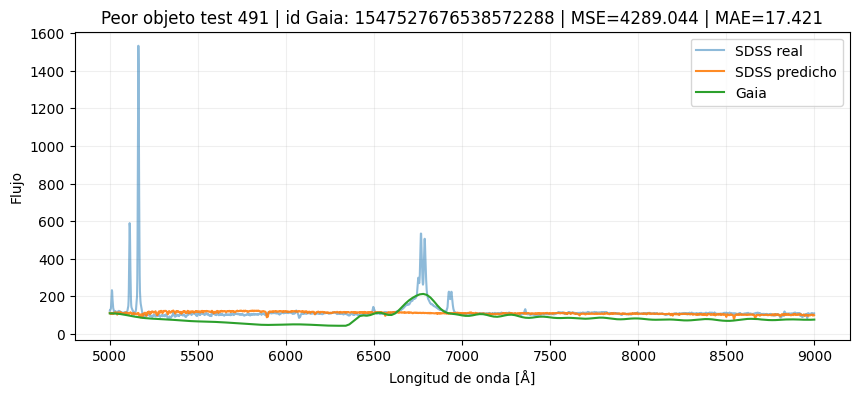

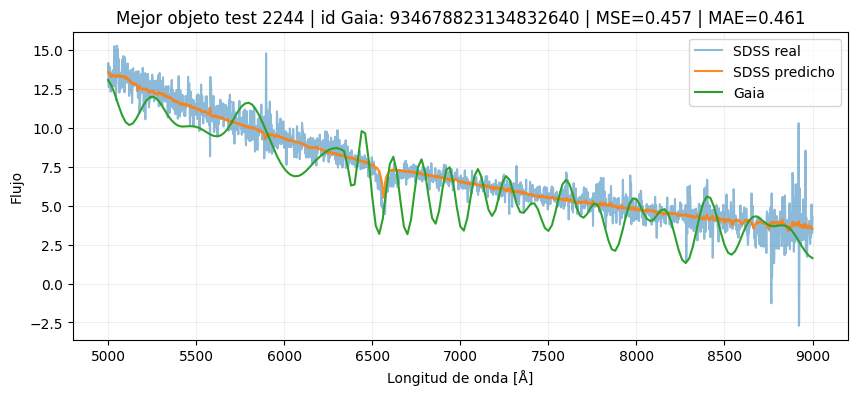

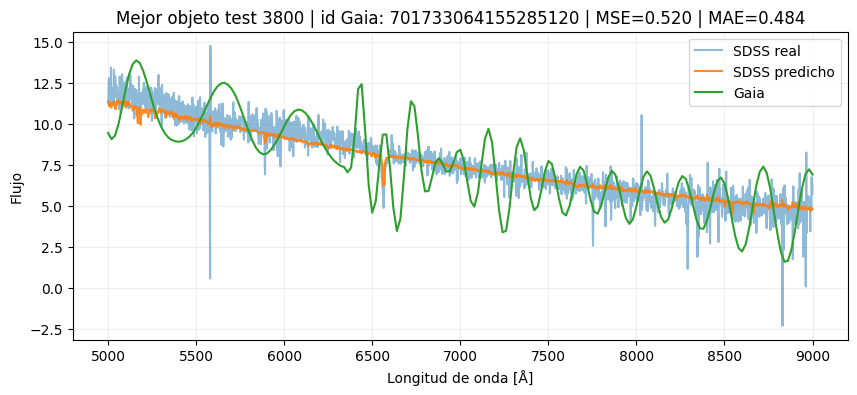

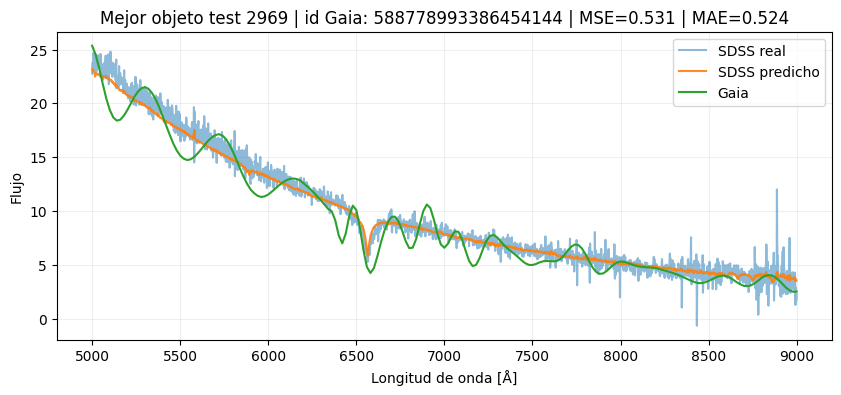

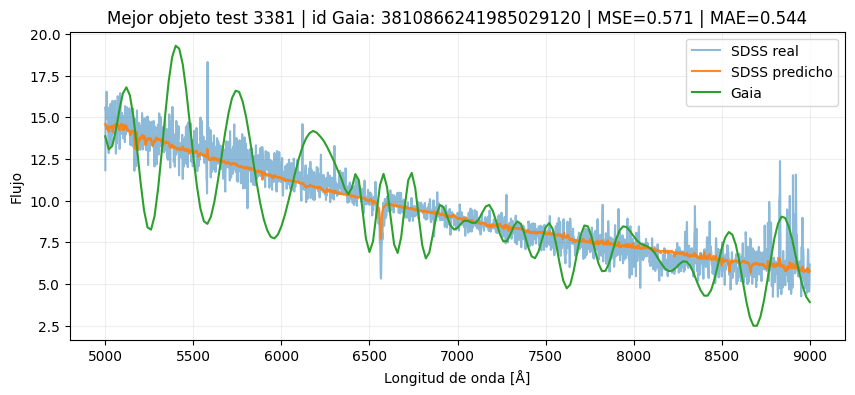

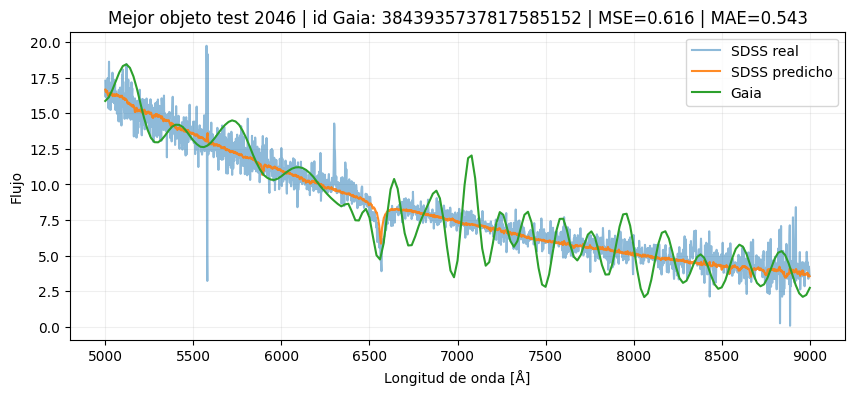

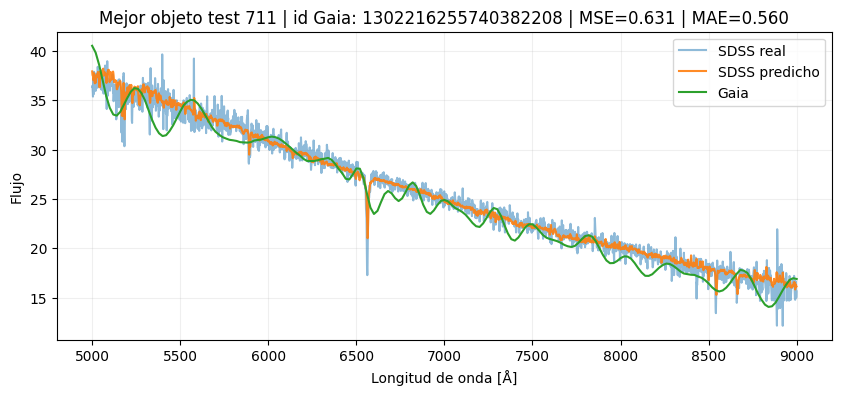

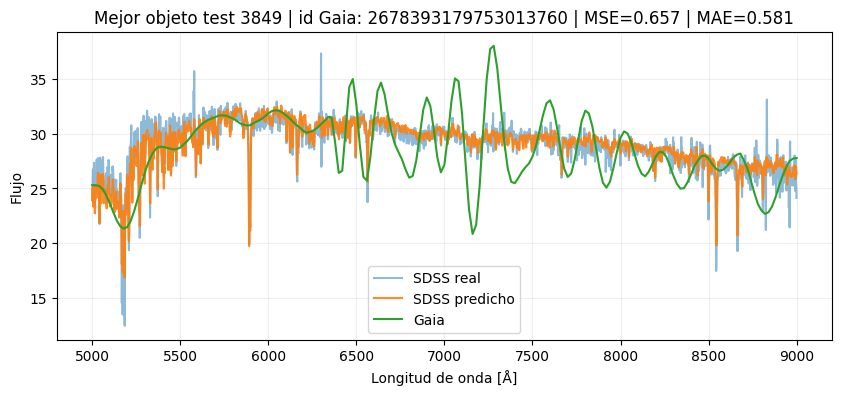

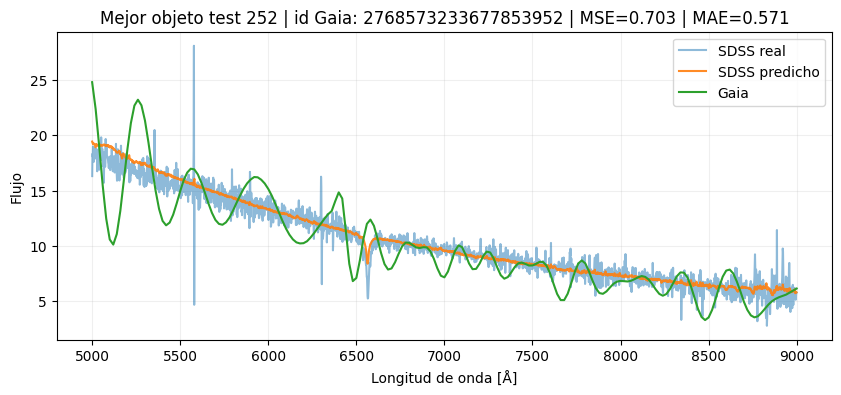

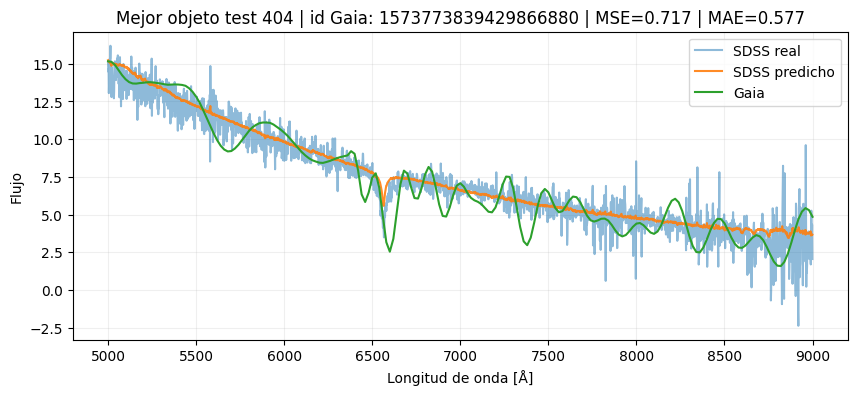

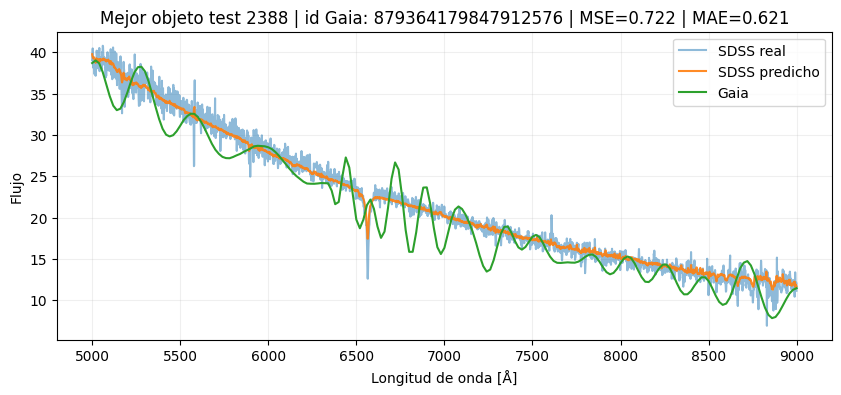

In [33]:
plot_worst_best_predictions(
    y_test,
    y_pred_spec_GRU,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [16]:
class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.attention_dense = layers.Dense(1)
        super().build(input_shape)

    def call(self, inputs):
        scores = self.attention_dense(inputs)
        weights = tf.nn.softmax(scores, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context

In [17]:
early_stop_earlier = EarlyStopping(
    monitor="val_loss",
    patience=2,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr_earlier = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)


In [18]:
model_birnn_simple = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.Bidirectional(layers.GRU(128, return_sequences=False)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_birnn_simple.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_birnn_simple.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,589,354 (21.32 MB)

 Trainable params: 5,589,354 (21.32 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_birnn_simple = model_birnn_simple.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_earlier, reduce_lr_earlier],
    verbose=1
)

Epoch 1/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 203s 384ms/step - loss: 0.1081 - mae: 0.2892 - mse: 0.2397 - val_loss: 0.0060 - val_mae: 0.0622 - val_mse: 0.0177 - learning_rate: 1.0000e-04
Epoch 2/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 172s 337ms/step - loss: 0.0058 - mae: 0.0606 - mse: 0.0148 - val_loss: 0.0053 - val_mae: 0.0583 - val_mse: 0.0158 - learning_rate: 1.0000e-04
Epoch 3/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 180s 352ms/step - loss: 0.0051 - mae: 0.0550 - mse: 0.0134 - val_loss: 0.0050 - val_mae: 0.0537 - val_mse: 0.0149 - learning_rate: 1.0000e-04
Epoch 4/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 170s 332ms/step - loss: 0.0048 - mae: 0.0538 - mse: 0.0121 - val_loss: 0.0047 - val_mae: 0.0521 - val_mse: 0.0143 - learning_rate: 1.0000e-04
Epoch 5/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - loss: 0.0048 - mae: 0.0536 - mse: 0.0125
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
511/511 ━━━━━━━━━━━━━━━━━━━━ 175s 342ms/step - loss: 0.0048 - mae: 0.0536 - mse: 0.0125 - val_loss:

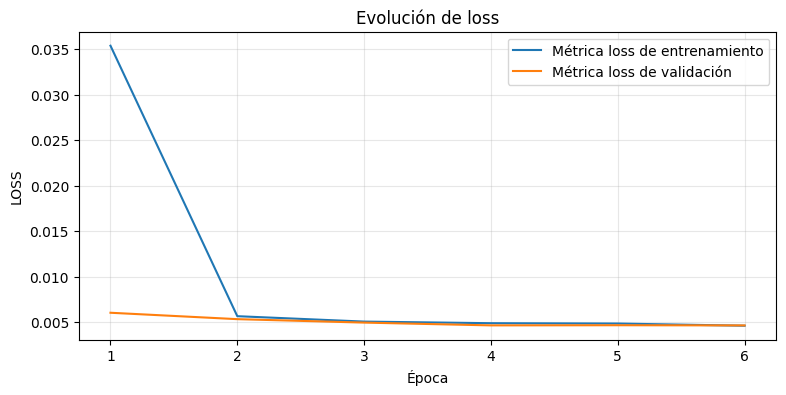

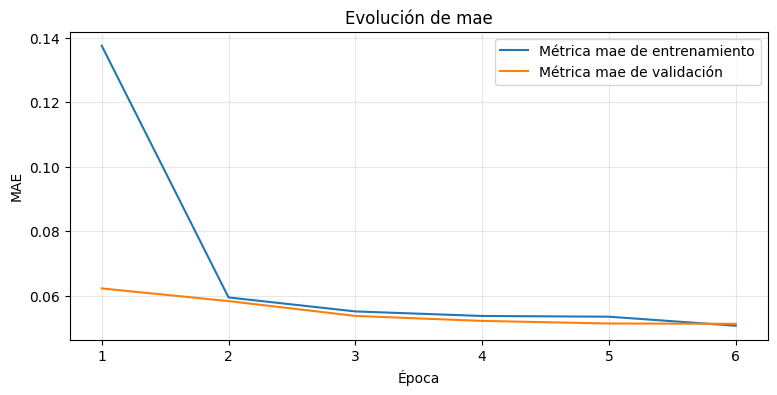

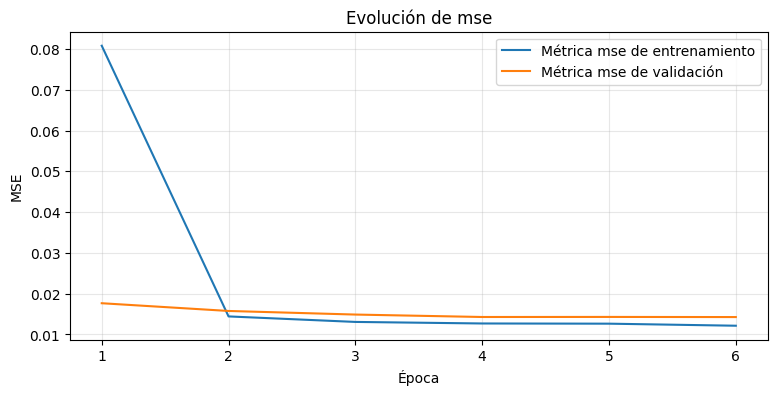

In [20]:
model_data_birnn = history_birnn_simple.history
plot_training_metrics(model_data_birnn)

In [21]:
test_results_birnn_simple_2 = model_birnn_simple.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.0047 - mae: 0.0524 - mse: 0.0129


In [22]:
y_pred_norm_birnn_simple= model_birnn_simple.predict(X_test_norm_median_spec)
y_pred_spec_birnn_simple= y_pred_norm_birnn_simple* y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step


In [23]:
predictions_path = Path("../data/predictions/predicciones_BIRNN_new.npz")
predictions_path.parent.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    predictions_path,
    y_pred_BIRNN_new = y_pred_spec_birnn_simple
)

In [ ]:
results_df_birnn_simple = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_birnn_simple,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE




Only LTE



Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-26 02:31:50,219] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.6911155921887264 -4.559396401646393 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 02:31:53,254] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-26 02:32:05,662] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.9241712653553704 -4.433403594384137 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 02:32:08,687] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-26 02:32:21,760] [WARNING] [atmospheres:_interpolate:114]: Target point '3538.718101860612 2.1204109244531257 -4.114757058193999 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-2

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE

[2026-08-26 04:10:55,319] [WARNING] [atmospheres:_interpolate:114]: Target point '6898.861174734105 4.405698264094979 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 04:10:58,351] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE


In [ ]:
ispec_path = Path("../data/predictions/ispec_GRU.csv")
ispec_path.parent.mkdir(parents=True, exist_ok=True)

results_df_birnn_simple.to_csv(
    ispec_path,
    index=False
)

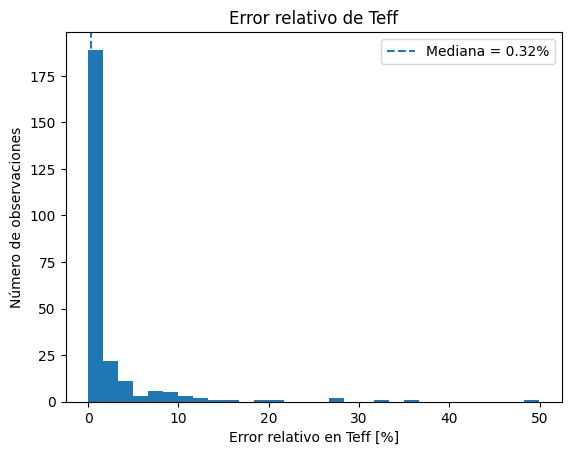

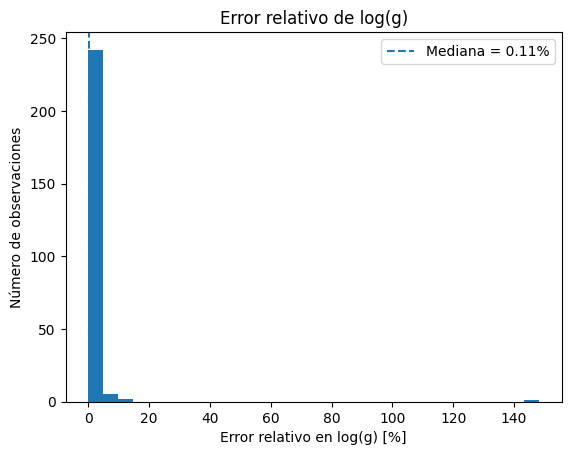

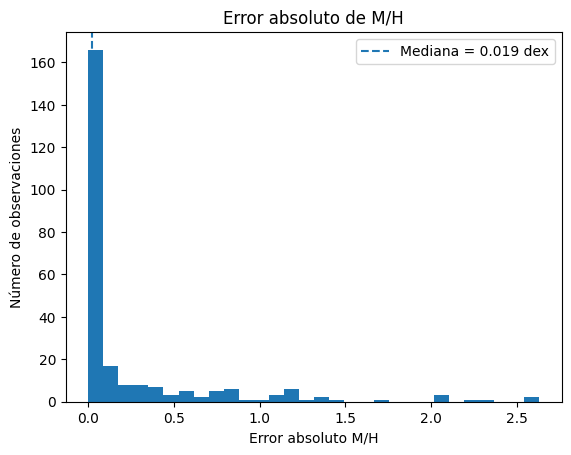

In [ ]:
error_birnn_simple = analyze_ispec_errors(results_df_birnn_simple)

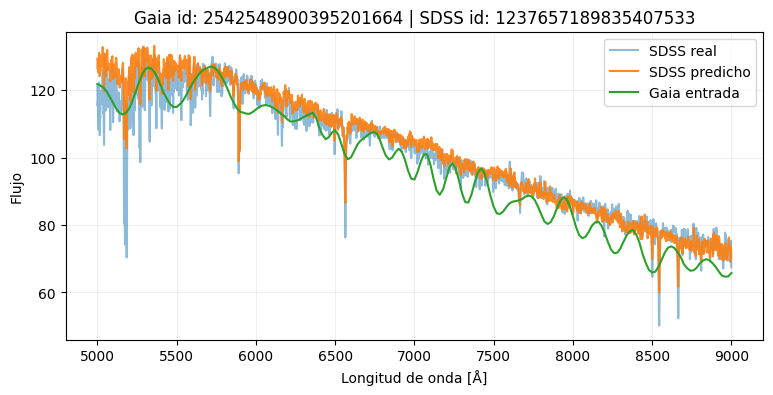

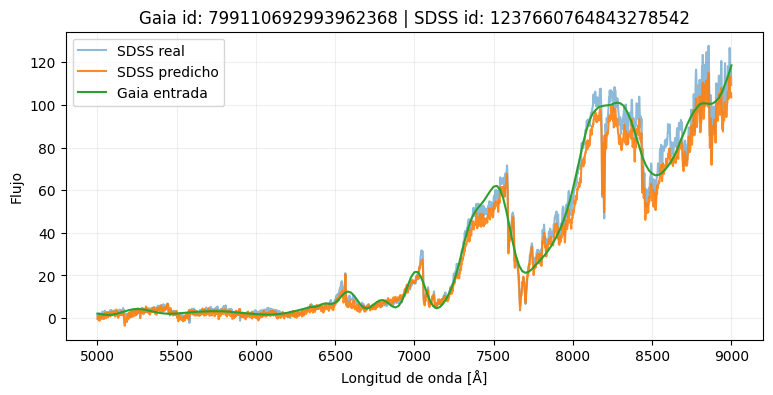

In [24]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_birnn_simple,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_birnn_simple,
    y_id_test,
    X_test,
    X_id_test
)

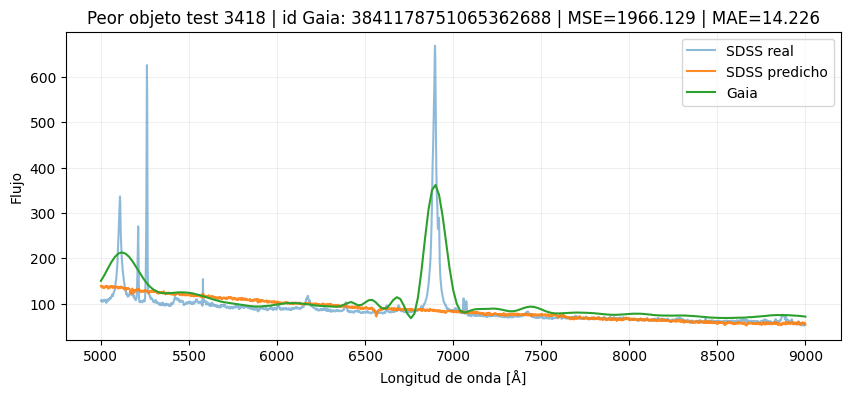

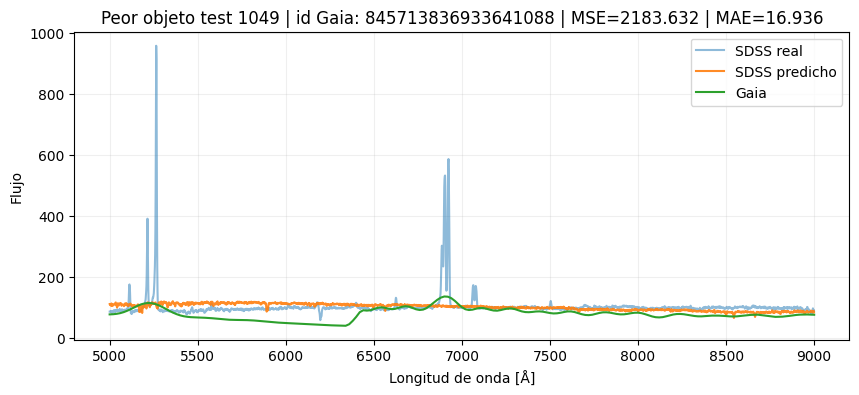

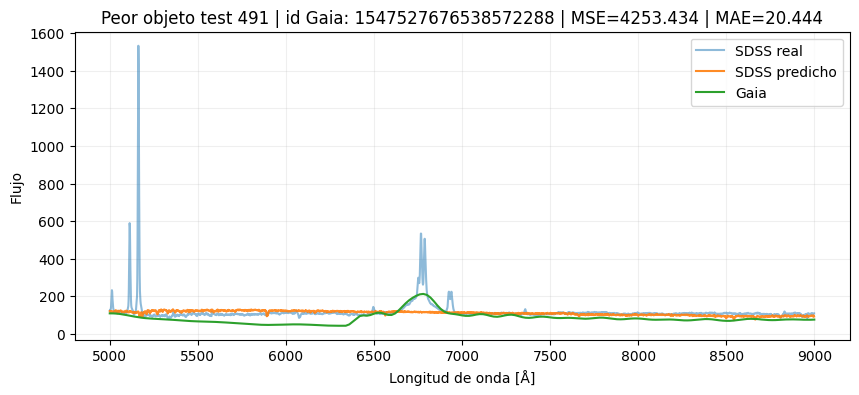

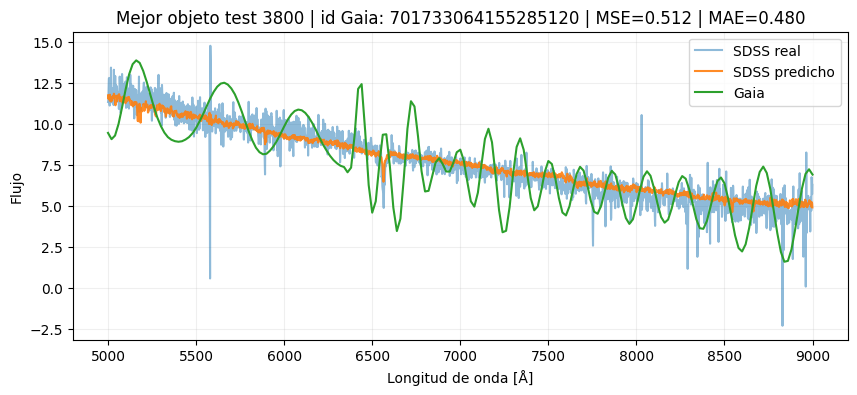

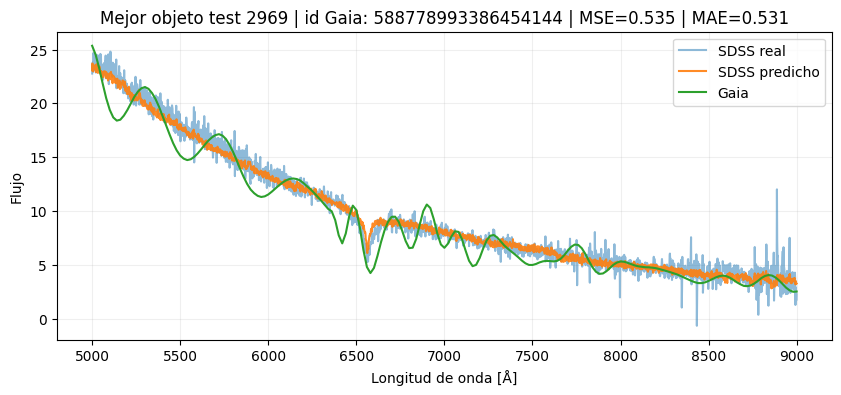

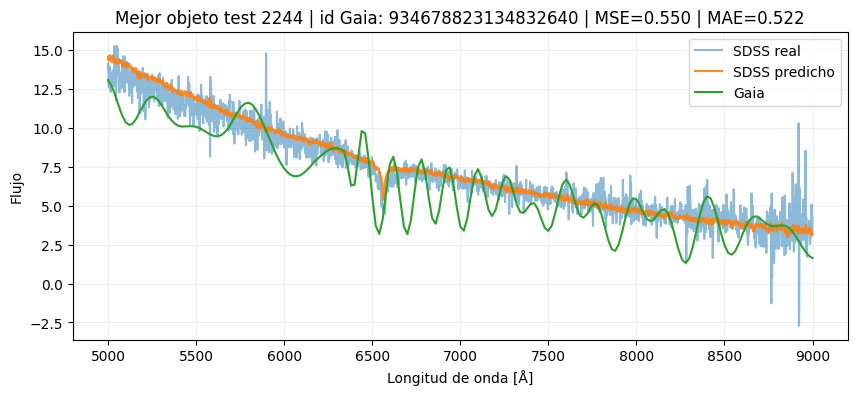

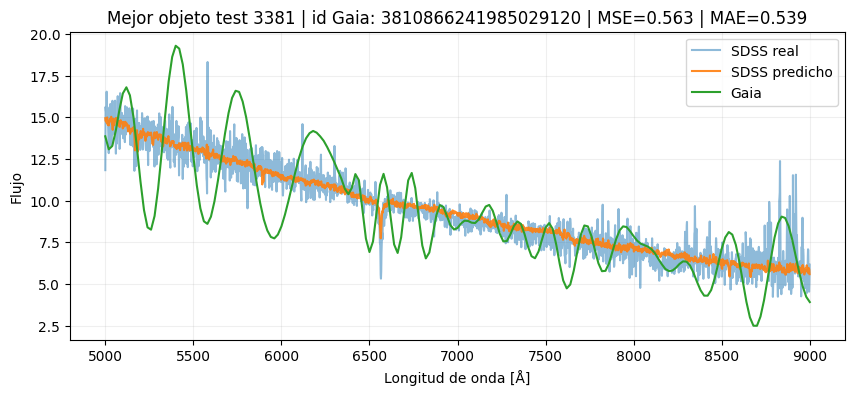

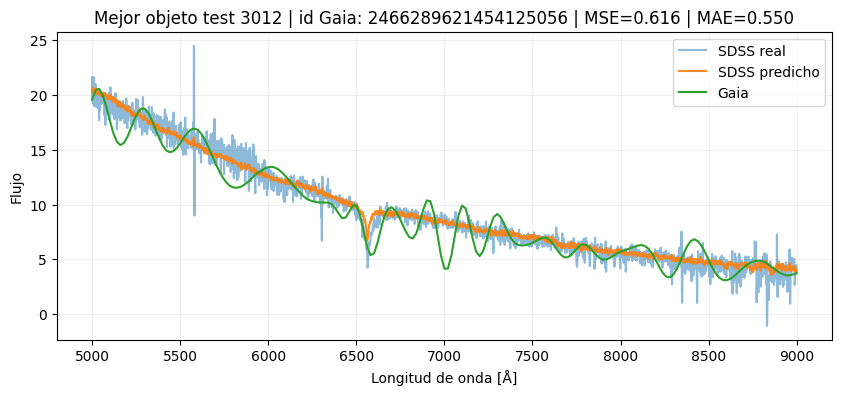

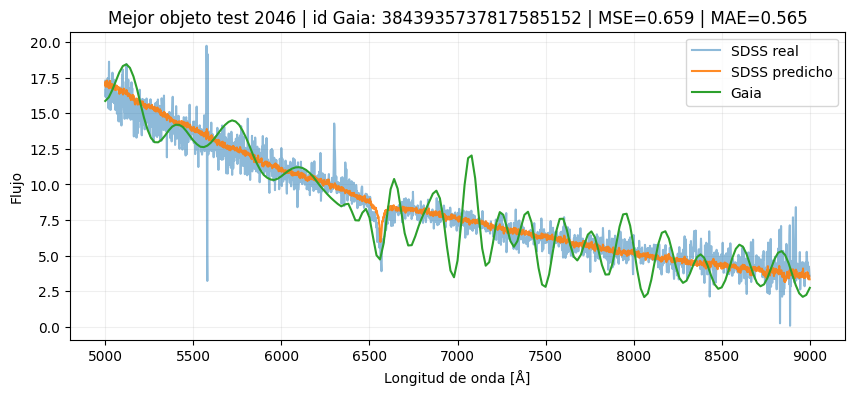

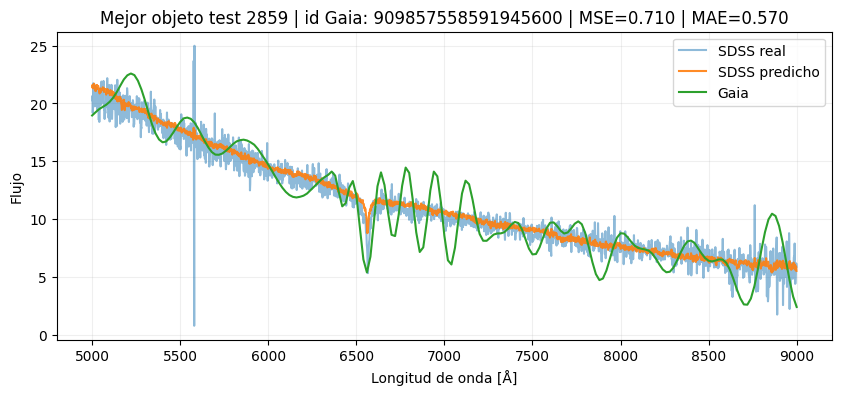

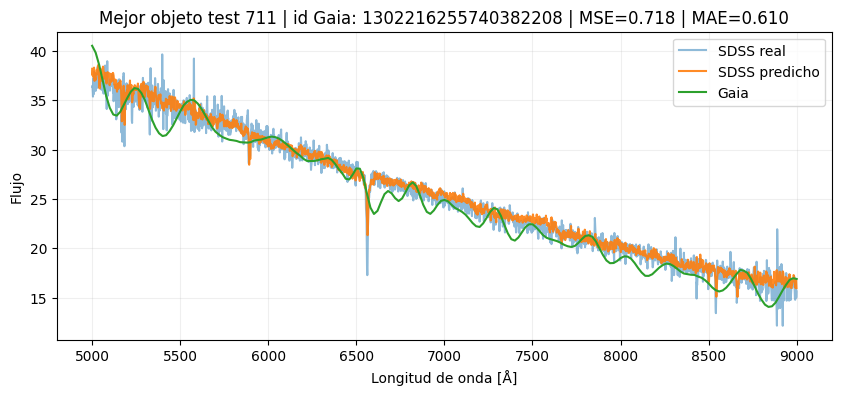

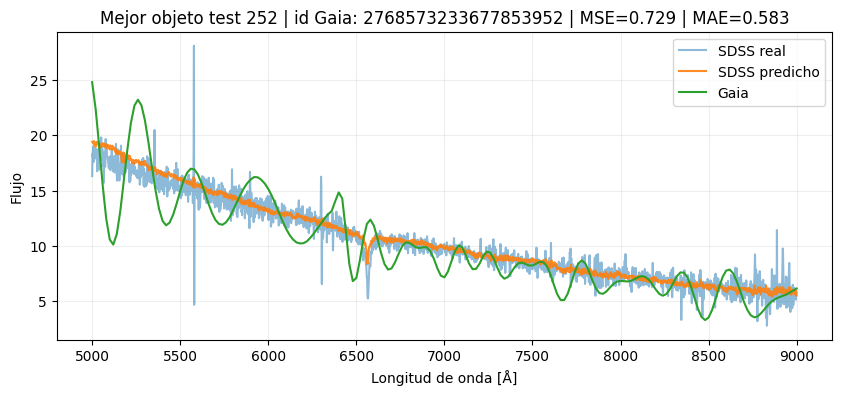

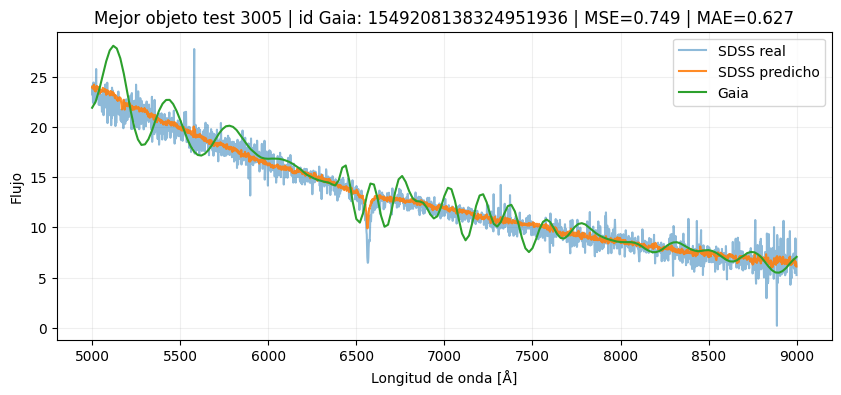

In [34]:
plot_worst_best_predictions(
    y_test,
    y_pred_spec_birnn_simple,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [25]:
inputs = layers.Input(shape=(n_gaia, n_features))

x = layers.Bidirectional(layers.GRU(128,return_sequences=True))(inputs)
x = layers.Bidirectional(layers.GRU(64,return_sequences=True))(x)

# Aplicamos Atención sobre todos los puntos del espectro
x = AttentionPooling()(x)

# Parte densa que ya hemos comprobado que funciona bien
x = layers.Dense(512)(x)
x = layers.LeakyReLU(negative_slope=0.01)(x)

x = layers.Dense(1024, activation="elu")(x)

x = layers.Dense(1024)(x)
x = layers.LeakyReLU(negative_slope=0.01)(x)

x = layers.Dense(1024, activation="elu")(x)

outputs = layers.Dense(n_sdss)(x)

model_birnn_attention = models.Model(inputs, outputs)

model_birnn_attention.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_birnn_attention.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 201, 256)       │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 201, 128)       │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling               │ (None, 128)            │           129 │
│ (AttentionPooling)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,647,595 (21.54 MB)

 Trainable params: 5,647,595 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history_birnn_attention = model_birnn_attention.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_earlier, reduce_lr_earlier],
    verbose=1
)

Epoch 1/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 278s 532ms/step - loss: 0.1294 - mae: 0.3481 - mse: 0.2933 - val_loss: 0.0514 - val_mae: 0.2172 - val_mse: 0.1256 - learning_rate: 1.0000e-04
Epoch 2/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 262s 513ms/step - loss: 0.0520 - mae: 0.2088 - mse: 0.1262 - val_loss: 0.0506 - val_mae: 0.2082 - val_mse: 0.1252 - learning_rate: 1.0000e-04
Epoch 3/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 258s 505ms/step - loss: 0.0396 - mae: 0.1730 - mse: 0.0961 - val_loss: 0.0062 - val_mae: 0.0653 - val_mse: 0.0176 - learning_rate: 1.0000e-04
Epoch 4/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 260s 509ms/step - loss: 0.0053 - mae: 0.0571 - mse: 0.0134 - val_loss: 0.0052 - val_mae: 0.0569 - val_mse: 0.0154 - learning_rate: 1.0000e-04
Epoch 5/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 263s 516ms/step - loss: 0.0050 - mae: 0.0545 - mse: 0.0126 - val_loss: 0.0050 - val_mae: 0.0544 - val_mse: 0.0150 - learning_rate: 1.0000e-04
Epoch 6/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 282s 552ms/step - loss: 0.0051 - mae: 0.0544 - mse

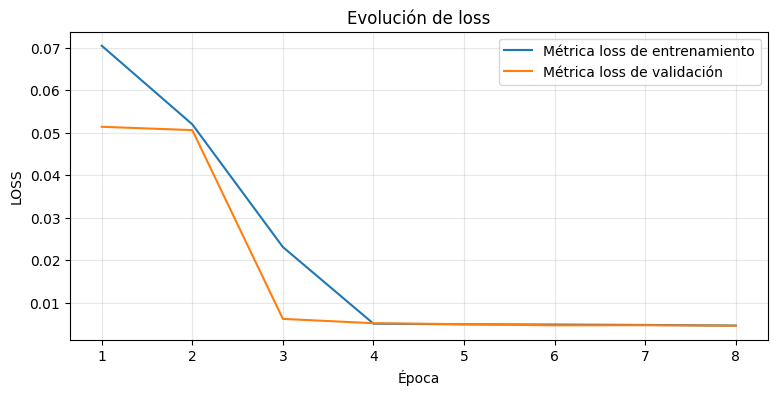

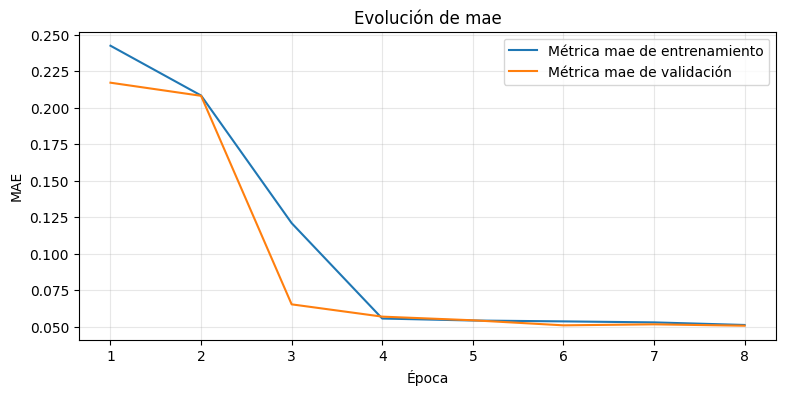

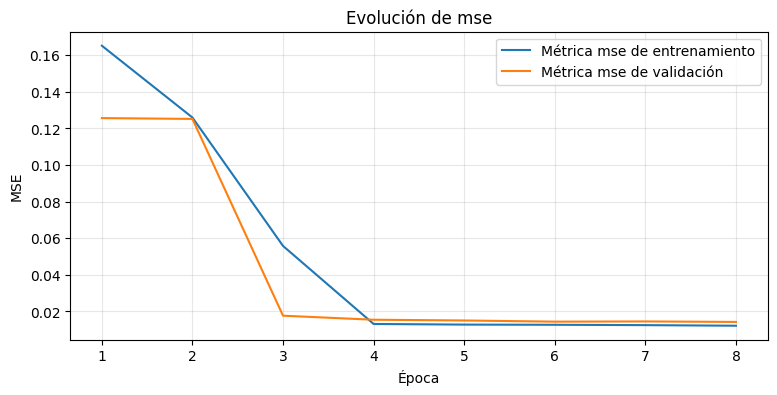

In [32]:
model_data_att = history_birnn_attention.history
plot_training_metrics(model_data_att)

In [27]:
test_results_rnn_attention = model_birnn_attention.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - loss: 0.0047 - mae: 0.0507 - mse: 0.0128


In [ ]:
y_pred_norm_birnn_attention= model_birnn_attention.predict(X_test_norm_median_spec)
y_pred_spec_birnn_attention= y_pred_norm_birnn_attention* y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step


In [29]:
predictions_path = Path("../data/predictions/predicciones_att_new.npz")
predictions_path.parent.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    predictions_path,
    y_pred_spec_birnn_attention = y_pred_spec_birnn_attention
)

In [ ]:
results_df_birnn_attention = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_birnn_attention,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE




Only LTE



Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-26 15:50:17,926] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.6911155921887264 -4.559396401646393 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 15:50:21,968] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-26 15:50:40,492] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.9241712653553704 -4.433403594384137 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 15:50:44,531] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-26 15:51:02,916] [WARNING] [atmospheres:_interpolate:114]: Target point '3538.718101860612 2.1204109244531257 -4.114757058193999 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-2

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE

[2026-08-26 18:00:51,621] [WARNING] [atmospheres:_interpolate:114]: Target point '6885.6399025060755 4.3976364084314765 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 18:00:54,653] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE


In [ ]:
ispec_path = Path("../data/predictions/ispec_attention_NEW.csv")
ispec_path.parent.mkdir(parents=True, exist_ok=True)

results_df_birnn_attention.to_csv(
    ispec_path,
    index=False
)

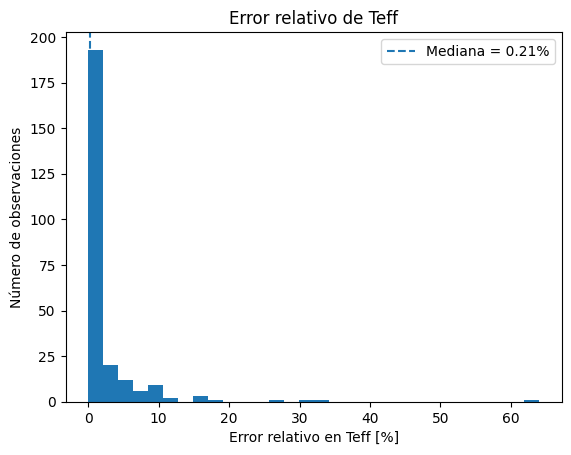

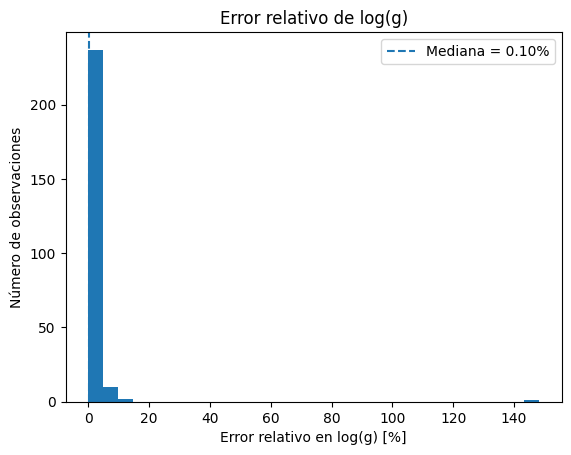

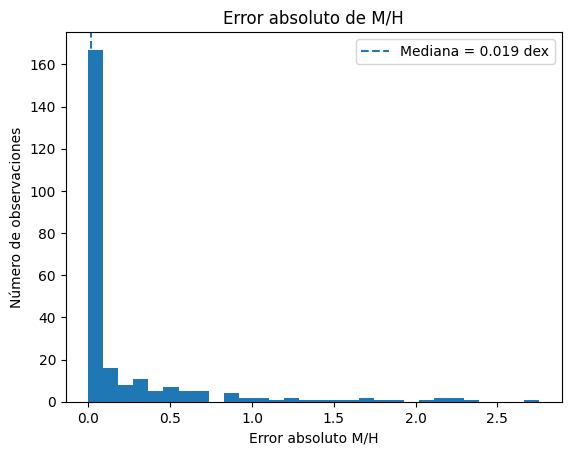

In [ ]:
error_birnn_attention = analyze_ispec_errors(results_df_birnn_attention)

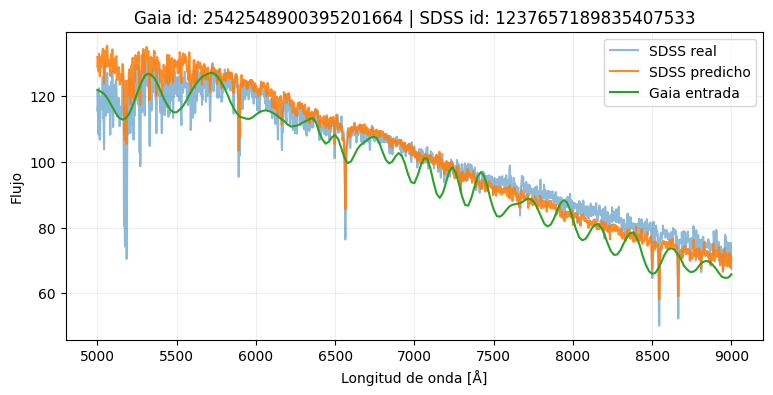

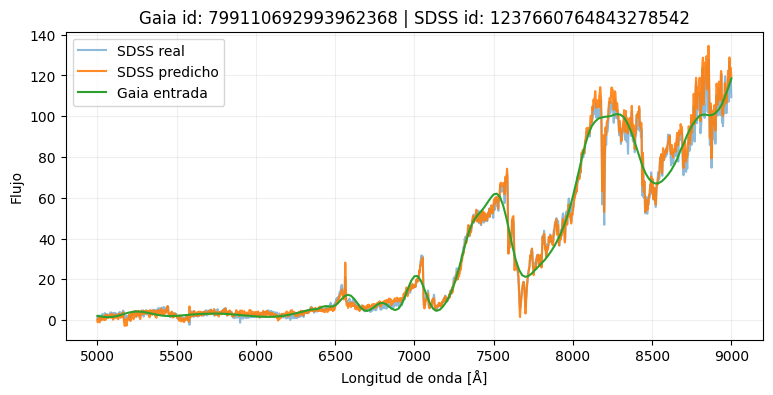

In [30]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_birnn_attention,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_birnn_attention,
    y_id_test,
    X_test,
    X_id_test
)

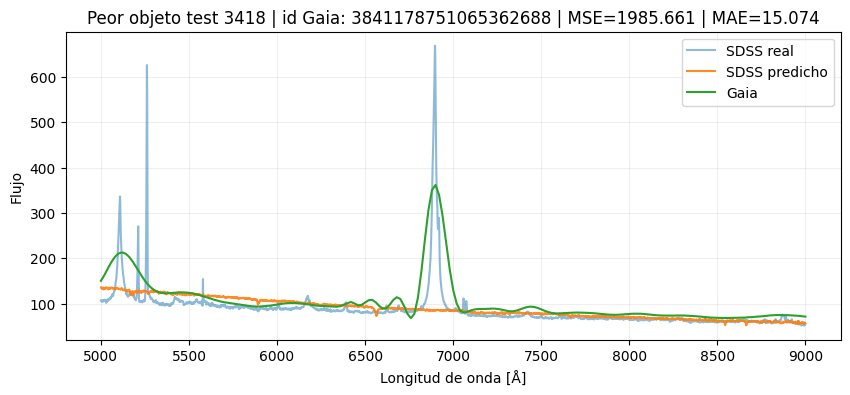

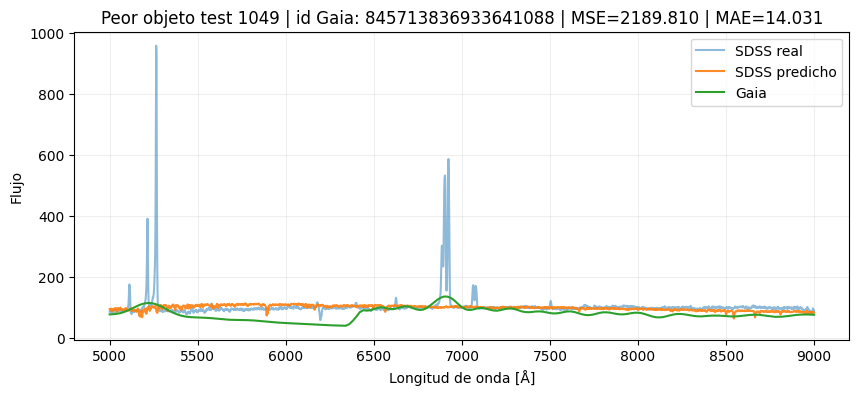

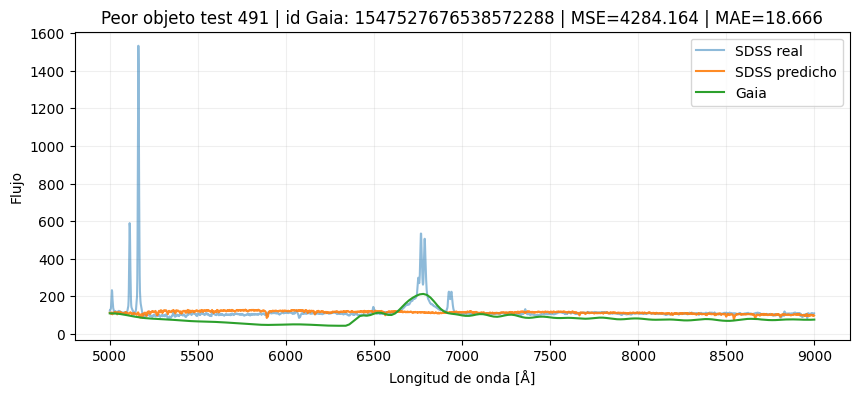

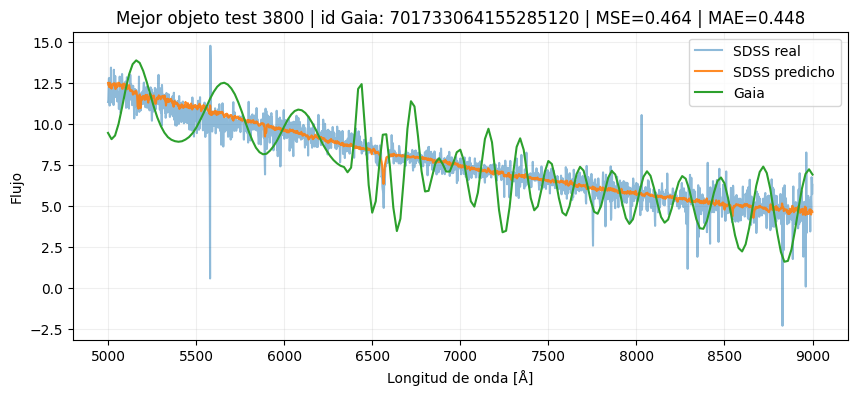

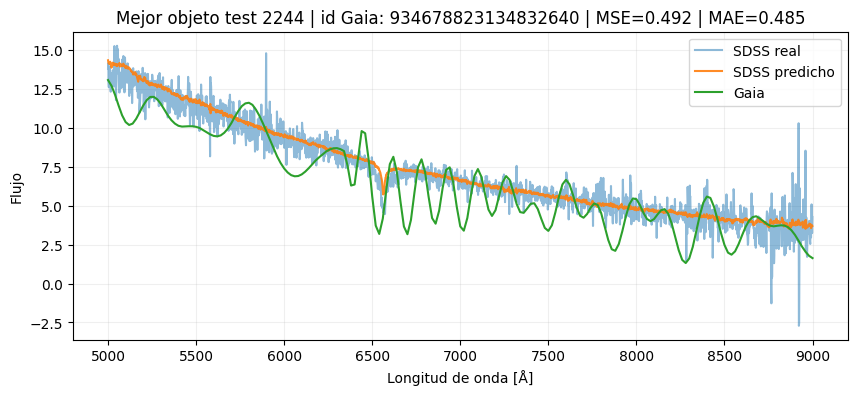

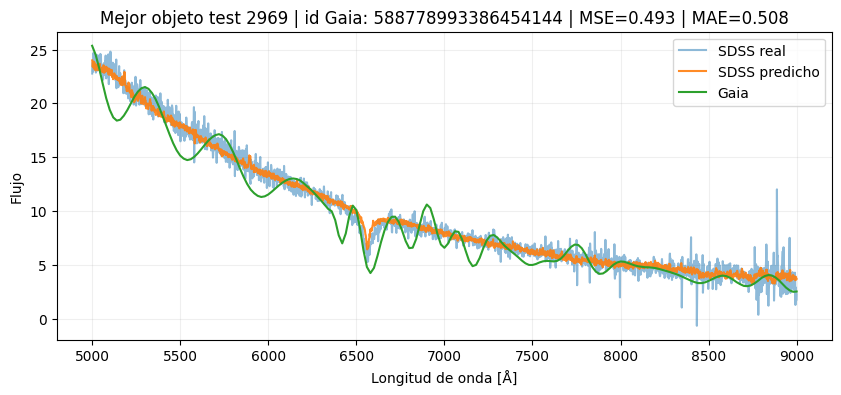

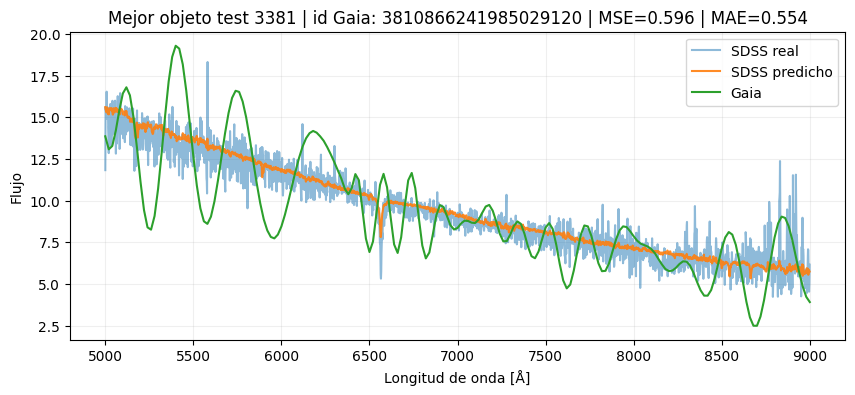

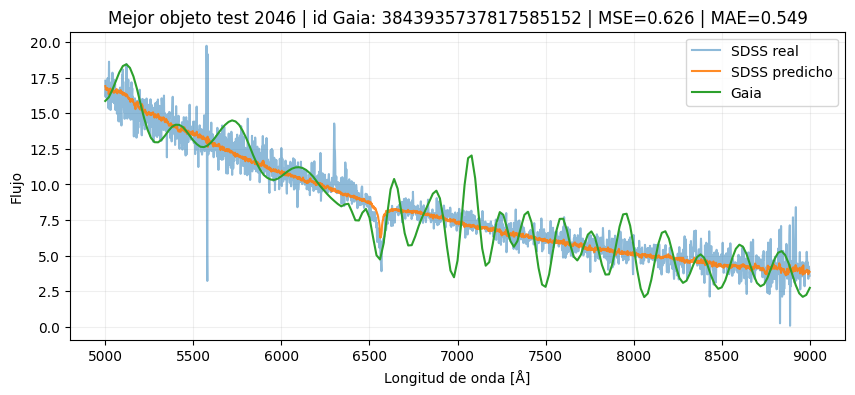

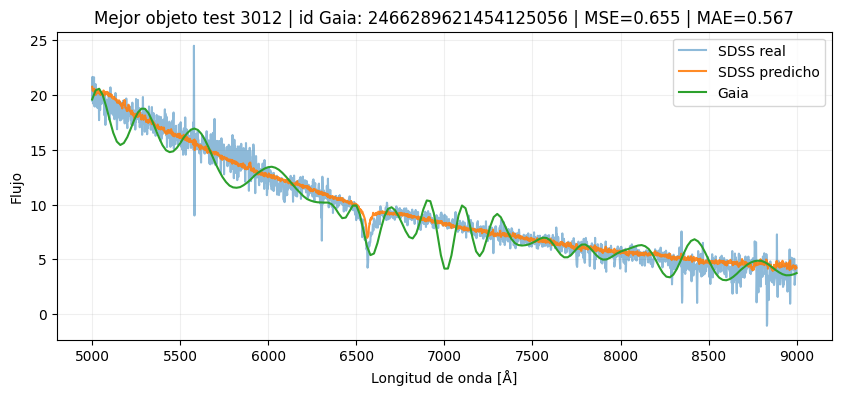

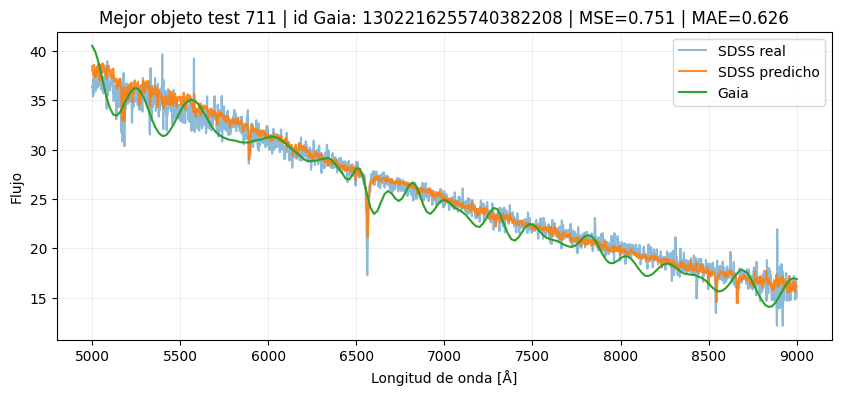

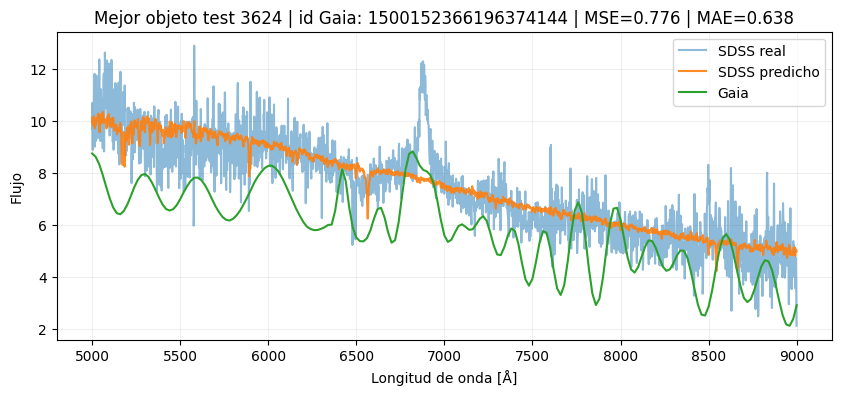

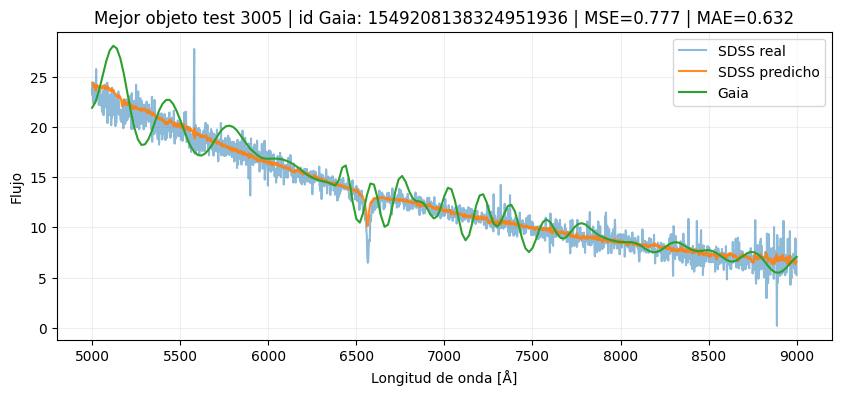

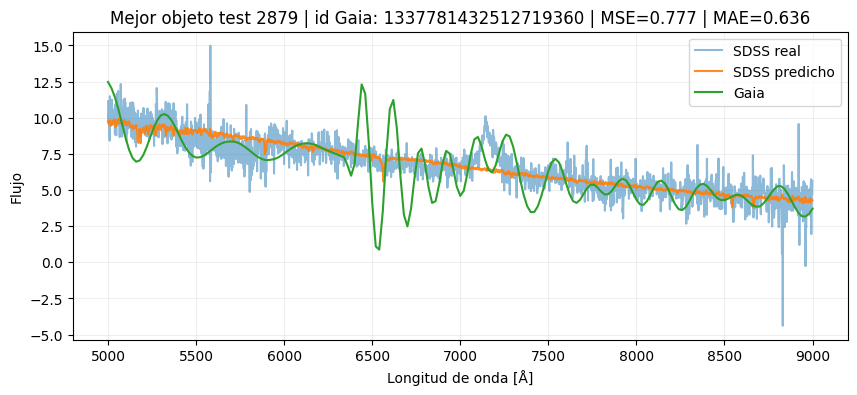

In [35]:
plot_worst_best_predictions(
    y_test,
    y_pred_spec_birnn_attention,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [ ]:
#predictions_path = Path("../data/predictions/predicciones_modelos_BIRNN_3.npz")
#predictions_path.parent.mkdir(parents=True, exist_ok=True)

#np.savez_compressed(
 #   predictions_path,
    
    # Predicciones de los modelos testeados
    #y_pred_birnn_attention = y_pred_birnn_attention,
   # y_pred_birnn_simple = y_pred_birnn_simple,
    #y_pred_spec_std = y_pred_spec,
  #  y_pred_spec_birnn_attention_2 = y_pred_spec_birnn_attention_2,
  #  y_pred_spec_birnn_simple_2 = y_pred_spec_birnn_simple_2
 # y_pred_spec_small=y_pred_spec_small
#)